
Features: (4737, 23)
Target: (4737,)
Target stats - Mean: 72,243 TND, Std: 47,505 TND

Final data quality check:
  NaN in features: 0
  NaN in target: 0
  Inf in features: 0

Train set: (3789, 23)
Test set: (948, 23)

TRAINING IMPROVED MODELS

Training XGBoost_Tuned...

Train MAE: 7,880 TND
Test MAE:  9,206 TND
Train RMSE: 11,891 TND
Test RMSE:  13,682 TND
Train R²: 0.9377
Test R²:  0.9147
CV MAE (5-fold): 9,343 TND

TOP 15 FEATURE IMPORTANCES
              feature  importance
         transmission    0.279528
        model_encoded    0.197097
 puissance_fiscale_sq    0.060320
power_age_interaction    0.058356
         fuel_essence    0.057788
    depreciation_rate    0.052733
         fuel_hybride    0.046399
      fuel_electrique    0.039773
              car_age    0.037790
        brand_encoded    0.034627
          kilometrage    0.024042
   brand_fuel_essence    0.017923
               km_log    0.017812
    puissance_fiscale    0.015335
               is_new    0.011715

✓ Feat

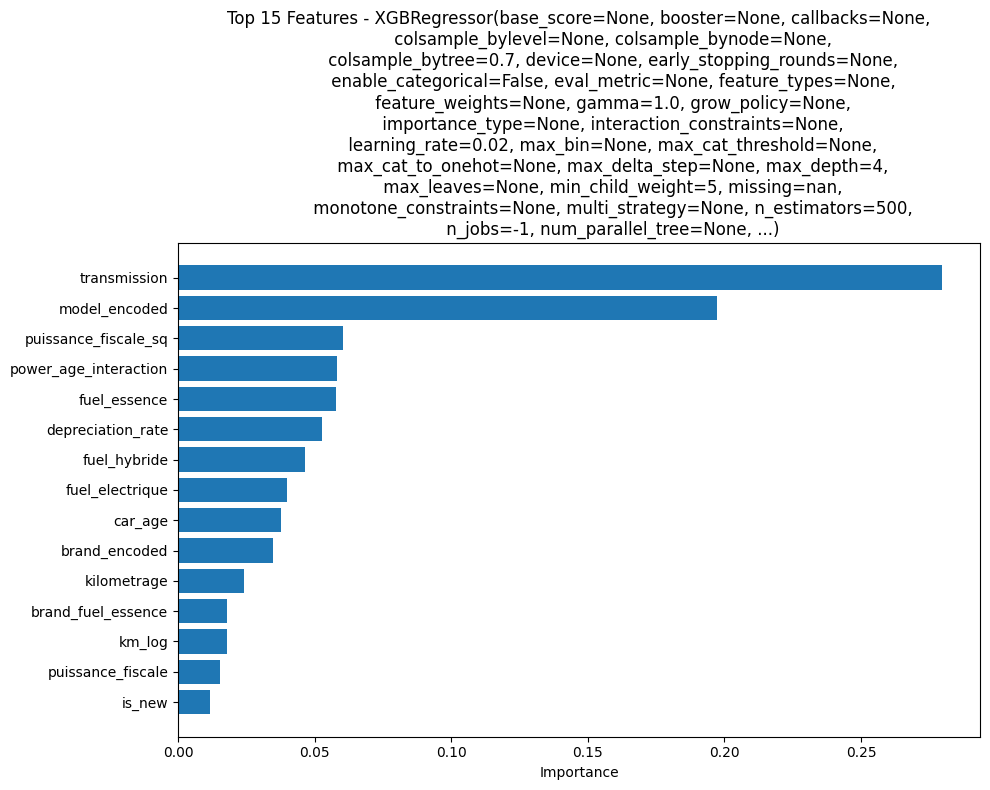

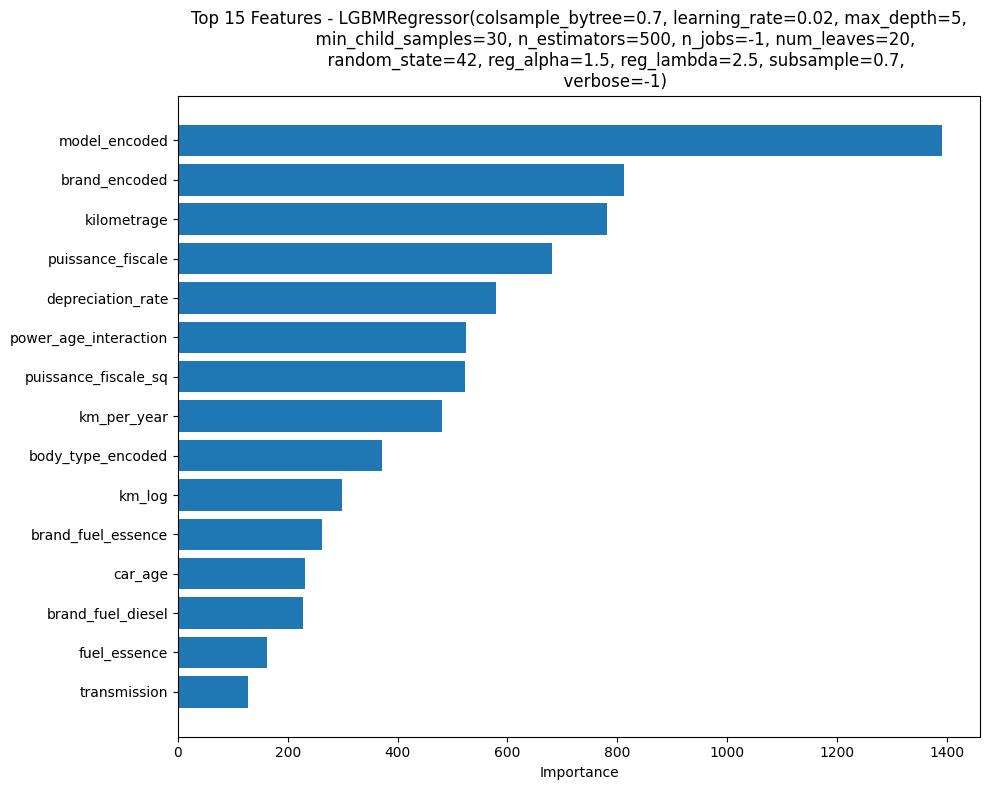

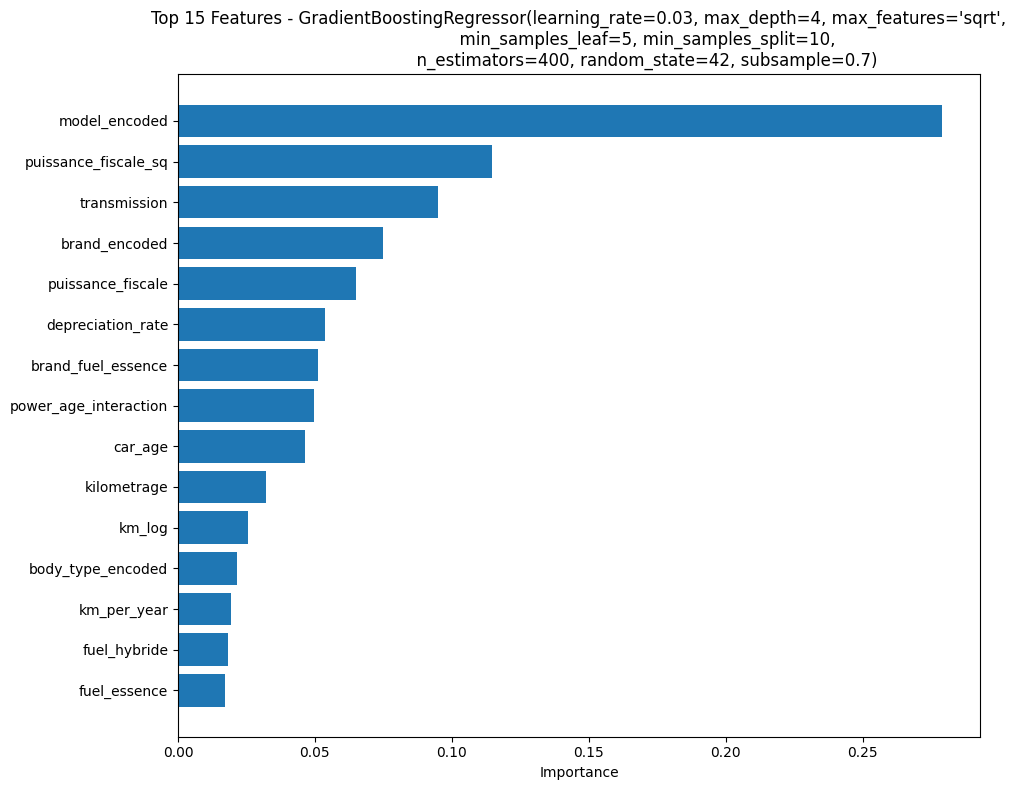

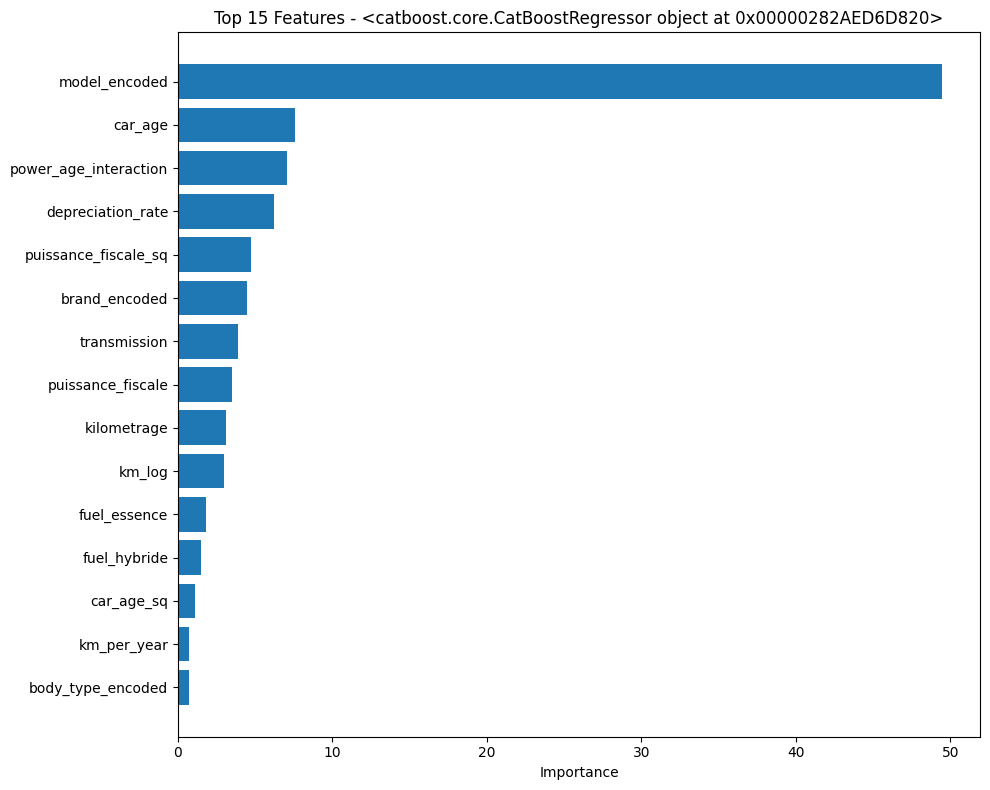

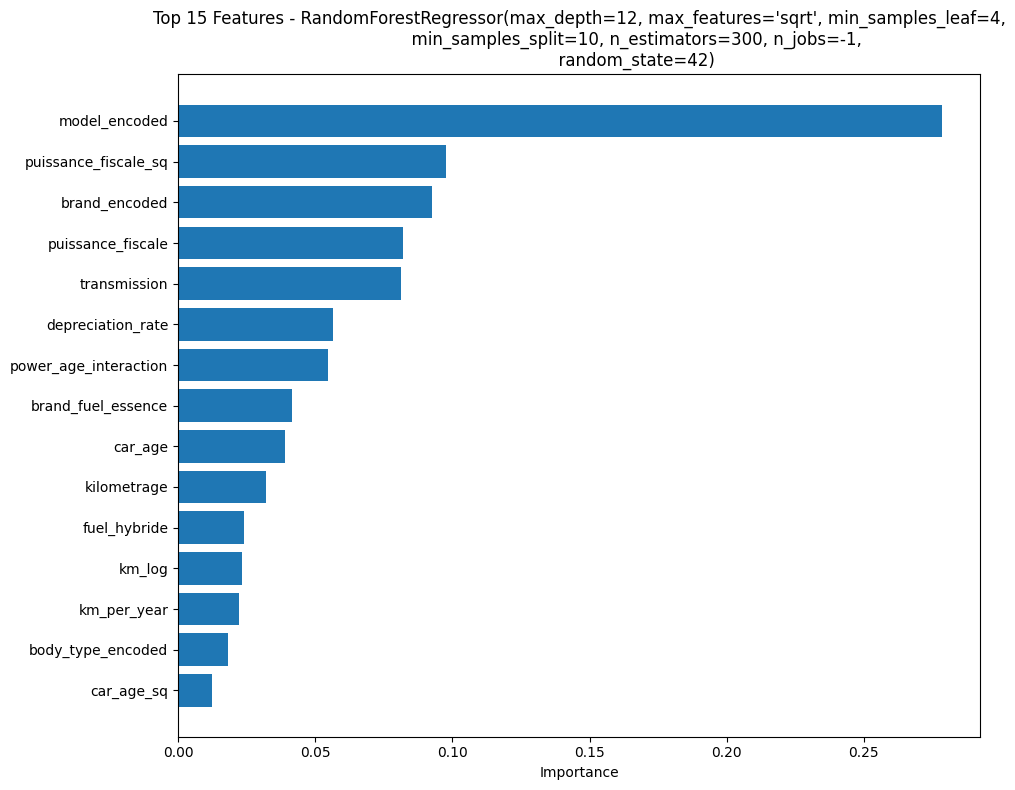

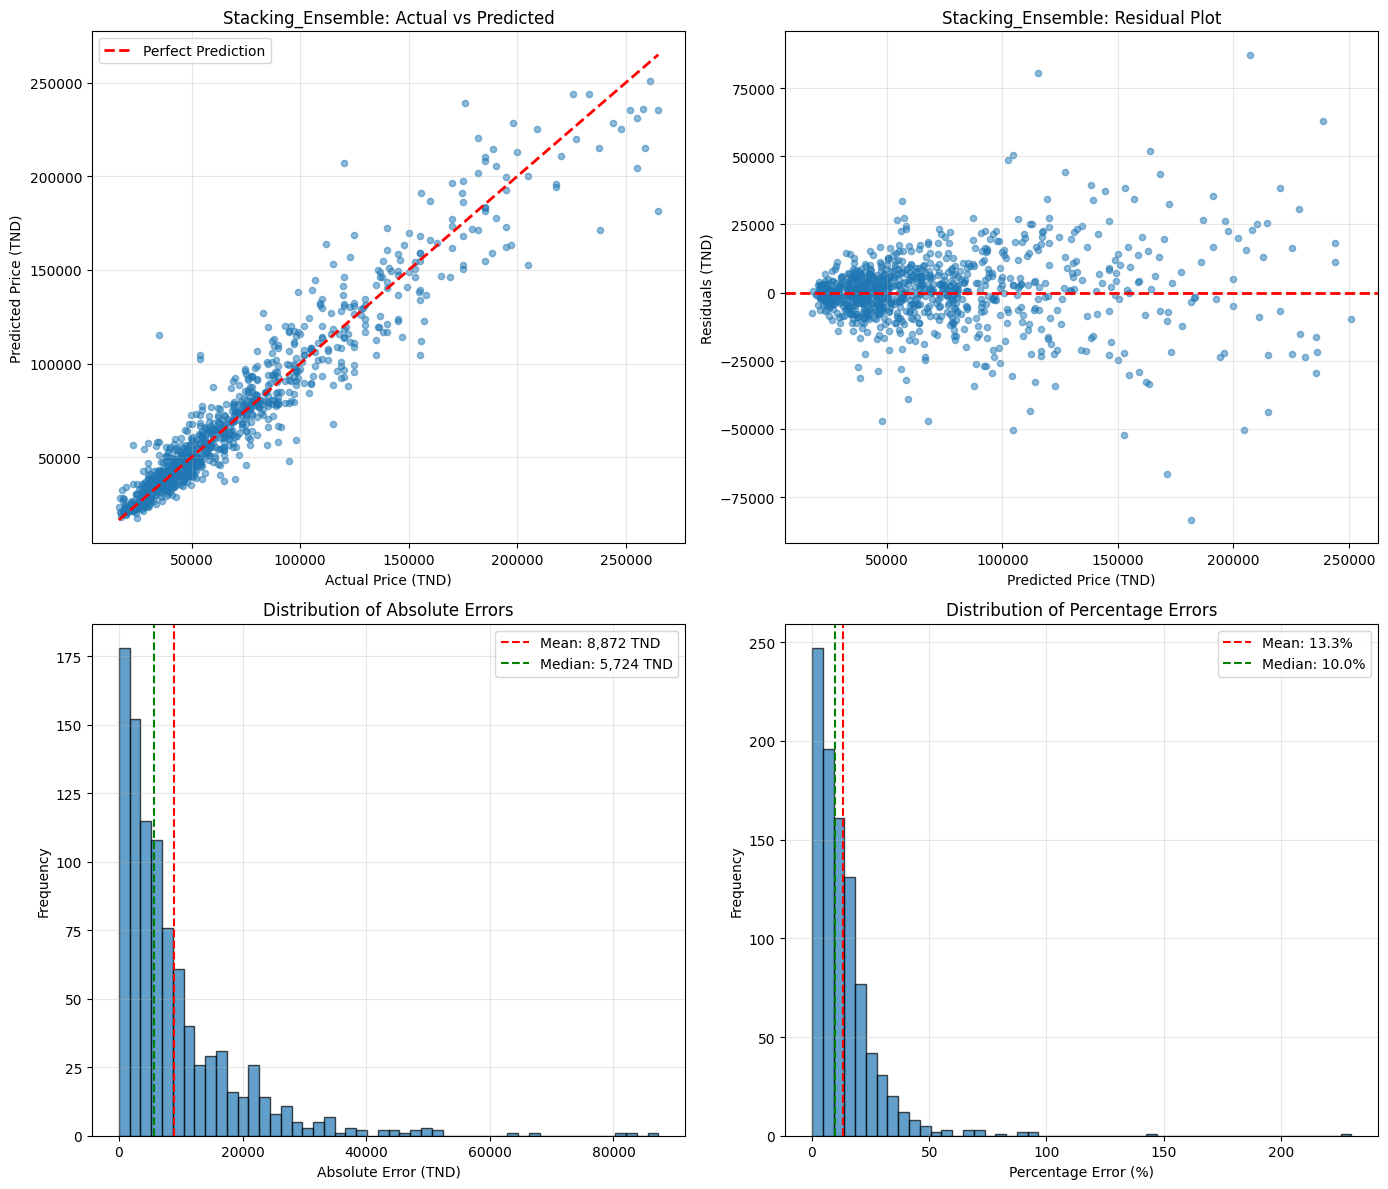

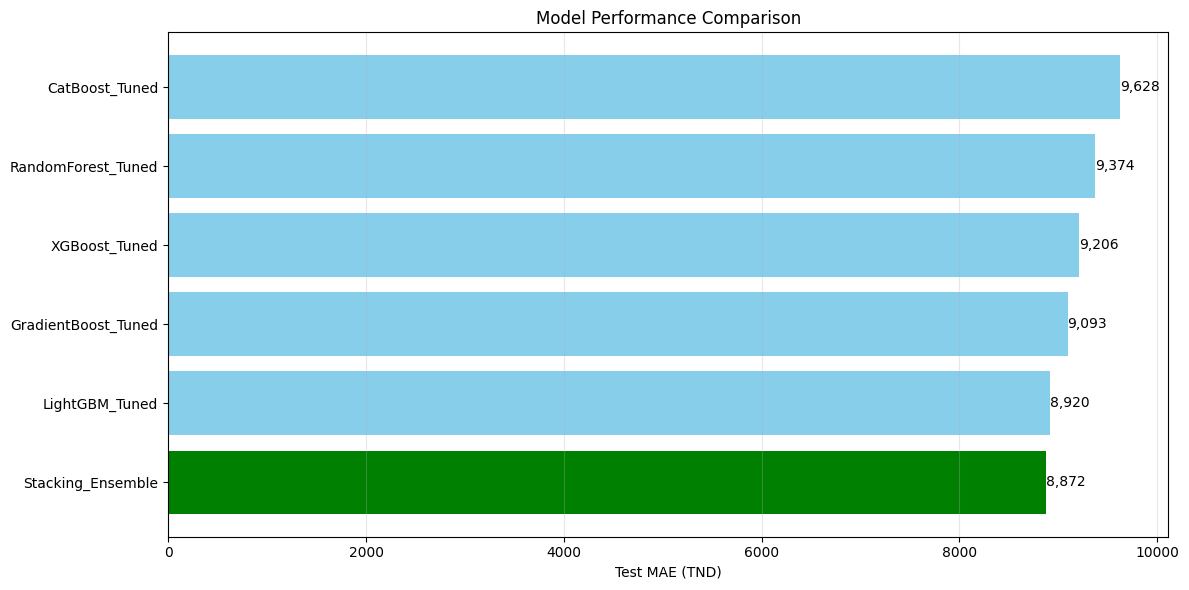

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')




df_clean=pd.read_csv(r'C:\Users\charn\Downloads\df_cleaned.csv')

features_to_drop = ['price', 'price_per_fiscal']

# Only drop columns that exist
features_to_drop = [col for col in features_to_drop if col in df_clean.columns]

X = df_clean.drop(features_to_drop, axis=1)
y = df_clean['price']

print(f"\nFeatures: {X.shape}")
print(f"Target: {y.shape}")
print(f"Target stats - Mean: {y.mean():,.0f} TND, Std: {y.std():,.0f} TND")

# Final NaN check
print(f"\nFinal data quality check:")
print(f"  NaN in features: {X.isnull().sum().sum()}")
print(f"  NaN in target: {y.isnull().sum()}")
print(f"  Inf in features: {np.isinf(X.select_dtypes(include=[np.number]).values).sum()}")

if X.isnull().sum().sum() > 0 or y.isnull().sum() > 0:
    print("⚠ ERROR: Still have NaN values. Dropping rows with NaN...")
    mask = ~(X.isnull().any(axis=1) | y.isnull())
    X = X[mask]
    y = y[mask]
    print(f"  New shape: {X.shape}")

# ============================================
# STEP 1: Train-Test Split
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=pd.qcut(y, q=5, labels=False, duplicates='drop')
)

print(f"\nTrain set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# ============================================
# STEP 2: Optional - Log Transform Target (Uncomment if needed)
# ============================================
# This helps with skewed price distributions
USE_LOG_TRANSFORM = False  # Set to True to enable

if USE_LOG_TRANSFORM:
    y_train_original = y_train.copy()
    y_test_original = y_test.copy()
    y_train = np.log1p(y_train)
    y_test = np.log1p(y_test)
    print("\n✓ Log transformation applied to target variable")

# ============================================
# STEP 3: Train Improved Models
# ============================================
print("\n" + "="*60)
print("TRAINING IMPROVED MODELS")
print("="*60)

models = {
    'XGBoost_Tuned': xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.02,
        max_depth=4,
        min_child_weight=5,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=1.0,
        reg_lambda=2.0,
        gamma=1.0,
        random_state=42,
        n_jobs=-1
    ),
    'LightGBM_Tuned': lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.02,
        max_depth=5,
        num_leaves=20,
        min_child_samples=30,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=1.5,
        reg_lambda=2.5,
        random_state=42,
        verbose=-1,
        n_jobs=-1
    ),
    'GradientBoost_Tuned': GradientBoostingRegressor(
        n_estimators=400,
        learning_rate=0.03,
        max_depth=4,
        min_samples_split=10,
        min_samples_leaf=5,
        subsample=0.7,
        max_features='sqrt',
        random_state=42
    ),
    'CatBoost_Tuned': CatBoostRegressor(
        iterations=500,
        learning_rate=0.02,
        depth=5,
        l2_leaf_reg=7.0,
        random_state=42,
        verbose=0
    ),
    'RandomForest_Tuned': RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
}

results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {name}...")
    print(f"{'='*60}")

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Reverse log transform if used
    if USE_LOG_TRANSFORM:
        y_train_pred = np.expm1(y_train_pred)
        y_test_pred = np.expm1(y_test_pred)
        y_train_eval = y_train_original
        y_test_eval = y_test_original
    else:
        y_train_eval = y_train
        y_test_eval = y_test

    # Metrics
    train_mae = mean_absolute_error(y_train_eval, y_train_pred)
    test_mae = mean_absolute_error(y_test_eval, y_test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train_eval, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test_eval, y_test_pred))

    train_r2 = r2_score(y_train_eval, y_train_pred)
    test_r2 = r2_score(y_test_eval, y_test_pred)

    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train,
                                 cv=5, scoring='neg_mean_absolute_error',
                                 n_jobs=-1)
    cv_mae = -cv_scores.mean()

    if USE_LOG_TRANSFORM:
        cv_mae = np.expm1(cv_mae)

    results[name] = {
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'cv_mae': cv_mae,
        'model': model,
        'test_pred': y_test_pred
    }

    print(f"\nTrain MAE: {train_mae:,.0f} TND")
    print(f"Test MAE:  {test_mae:,.0f} TND")
    print(f"Train RMSE: {train_rmse:,.0f} TND")
    print(f"Test RMSE:  {test_rmse:,.0f} TND")
    print(f"Train R²: {train_r2:.4f}")
    print(f"Test R²:  {test_r2:.4f}")
    print(f"CV MAE (5-fold): {cv_mae:,.0f} TND")

    if hasattr(model, 'feature_importances_'):
      print("\n" + "="*60)
      print("TOP 15 FEATURE IMPORTANCES")
      print("="*60)

      feature_importance = pd.DataFrame({
          'feature': X_train.columns,
          'importance': model.feature_importances_
      }).sort_values('importance', ascending=False)

      print(feature_importance.head(15).to_string(index=False))

      # Plot
      plt.figure(figsize=(10, 8))
      top_features = feature_importance.head(15)
      plt.barh(range(len(top_features)), top_features['importance'])
      plt.yticks(range(len(top_features)), top_features['feature'])
      plt.xlabel('Importance')
      plt.title(f'Top 15 Features - {model}')
      plt.gca().invert_yaxis()
      plt.tight_layout()
      plt.savefig('feature_importance_improved.png', dpi=300, bbox_inches='tight')
      print("\n✓ Feature importance plot saved")
     

# ============================================
# STEP 4: Stacking Ensemble
# ============================================
print(f"\n{'='*60}")
print("Training STACKING ENSEMBLE...")
print(f"{'='*60}")

# Select top 3 models for stacking
top_3_models = sorted(results.items(), key=lambda x: x[1]['test_mae'])[:3]
print(f"Stacking models: {[m[0] for m in top_3_models]}")

estimators = [(name, res['model']) for name, res in top_3_models]

stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1
)

stacking_model.fit(X_train, y_train)
y_train_pred_stack = stacking_model.predict(X_train)
y_test_pred_stack = stacking_model.predict(X_test)

# Reverse log transform if used
if USE_LOG_TRANSFORM:
    y_train_pred_stack = np.expm1(y_train_pred_stack)
    y_test_pred_stack = np.expm1(y_test_pred_stack)
    y_train_eval = y_train_original
    y_test_eval = y_test_original
else:
    y_train_eval = y_train
    y_test_eval = y_test

train_mae_stack = mean_absolute_error(y_train_eval, y_train_pred_stack)
test_mae_stack = mean_absolute_error(y_test_eval, y_test_pred_stack)
train_r2_stack = r2_score(y_train_eval, y_train_pred_stack)
test_r2_stack = r2_score(y_test_eval, y_test_pred_stack)

results['Stacking_Ensemble'] = {
    'train_mae': train_mae_stack,
    'test_mae': test_mae_stack,
    'train_rmse': np.sqrt(mean_squared_error(y_train_eval, y_train_pred_stack)),
    'test_rmse': np.sqrt(mean_squared_error(y_test_eval, y_test_pred_stack)),
    'train_r2': train_r2_stack,
    'test_r2': test_r2_stack,
    'cv_mae': np.nan,
    'model': stacking_model,
    'test_pred': y_test_pred_stack
}

print(f"\nTrain MAE: {train_mae_stack:,.0f} TND")
print(f"Test MAE:  {test_mae_stack:,.0f} TND")
print(f"Train R²: {train_r2_stack:.4f}")
print(f"Test R²:  {test_r2_stack:.4f}")

# ============================================
# STEP 5: Model Comparison
# ============================================
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test MAE': [results[m]['test_mae'] for m in results.keys()],
    'Test RMSE': [results[m]['test_rmse'] for m in results.keys()],
    'Test R²': [results[m]['test_r2'] for m in results.keys()],
    'Train-Test Gap': [results[m]['train_mae'] - results[m]['test_mae'] for m in results.keys()]
})

comparison_df = comparison_df.sort_values('Test MAE')
print(comparison_df.to_string(index=False))

best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['model']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Test MAE: {results[best_model_name]['test_mae']:,.0f} TND")
print(f"   Test R²: {results[best_model_name]['test_r2']:.4f}")
print(f"   Overfitting Gap: {comparison_df.iloc[0]['Train-Test Gap']:,.0f} TND")

# ============================================
# STEP 6: Feature Importance
# ============================================


# ============================================
# STEP 7: Detailed Prediction Analysis
# ============================================
print("\n" + "="*60)
print("PREDICTION ANALYSIS")
print("="*60)

if USE_LOG_TRANSFORM:
    y_test_eval = y_test_original
else:
    y_test_eval = y_test

test_predictions = results[best_model_name]['test_pred']

prediction_df = pd.DataFrame({
    'Actual': y_test_eval.values,
    'Predicted': test_predictions,
    'Error': test_predictions - y_test_eval.values,
    'Abs_Error': np.abs(test_predictions - y_test_eval.values),
    'Pct_Error': np.abs((test_predictions - y_test_eval.values) / y_test_eval.values * 100)
})

print("\nPrediction Statistics:")
print(f"Mean Absolute Error: {prediction_df['Abs_Error'].mean():,.0f} TND")
print(f"Median Absolute Error: {prediction_df['Abs_Error'].median():,.0f} TND")
print(f"Mean Percentage Error: {prediction_df['Pct_Error'].mean():.2f}%")
print(f"Median Percentage Error: {prediction_df['Pct_Error'].median():.2f}%")
print(f"\nAccuracy Thresholds:")
print(f"  Within 5k TND:  {(prediction_df['Abs_Error'] <= 5000).sum() / len(prediction_df) * 100:.1f}%")
print(f"  Within 10k TND: {(prediction_df['Abs_Error'] <= 10000).sum() / len(prediction_df) * 100:.1f}%")
print(f"  Within 15k TND: {(prediction_df['Abs_Error'] <= 15000).sum() / len(prediction_df) * 100:.1f}%")
print(f"  Within 20k TND: {(prediction_df['Abs_Error'] <= 20000).sum() / len(prediction_df) * 100:.1f}%")


under_10pct = (prediction_df['Pct_Error'] <= 10).mean() * 100
print(f"  Within 10% relative error: {under_10pct:.1f}%")
under_20pct = (prediction_df['Pct_Error'] <= 20).mean() * 100
print(f"  Within 20% relative error: {under_20pct:.1f}%")
under_30pct = (prediction_df['Pct_Error'] <= 30).mean() * 100
print(f"  Within 100% relative error: {under_30pct:.1f}%")
under_40pct = (prediction_df['Pct_Error'] <= 40).mean() * 100
print(f"  Within 100% relative error: {under_40pct:.1f}%")

print("\nBest Predictions (Lowest Error):")
print(prediction_df.nsmallest(5, 'Abs_Error')[['Actual', 'Predicted', 'Abs_Error', 'Pct_Error']].round(0).to_string(index=False))

print("\nWorst Predictions (Highest Error):")
print(prediction_df.nlargest(5, 'Abs_Error')[['Actual', 'Predicted', 'Abs_Error', 'Pct_Error']].round(0).to_string(index=False))



print("\nWorst Predictions (Highest Percentage Error):")
worst_pct = prediction_df.nlargest(5, 'Pct_Error')
print(
    worst_pct[['Actual', 'Predicted', 'Abs_Error', 'Pct_Error']]
    .round({'Actual': 0, 'Predicted': 0, 'Abs_Error': 0, 'Pct_Error': 1})
    .to_string(index=False)
)

max_pct = prediction_df['Pct_Error'].max()
print(f"\n🚨 Worst percentage error in test set: {max_pct:.1f}%")



# ============================================
# STEP 8: Visualizations
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Actual vs Predicted
axes[0, 0].scatter(y_test_eval, test_predictions, alpha=0.5, s=20)
axes[0, 0].plot([y_test_eval.min(), y_test_eval.max()],
                [y_test_eval.min(), y_test_eval.max()],
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Price (TND)')
axes[0, 0].set_ylabel('Predicted Price (TND)')
axes[0, 0].set_title(f'{best_model_name}: Actual vs Predicted')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals
residuals = test_predictions - y_test_eval
axes[0, 1].scatter(test_predictions, residuals, alpha=0.5, s=20)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Price (TND)')
axes[0, 1].set_ylabel('Residuals (TND)')
axes[0, 1].set_title(f'{best_model_name}: Residual Plot')
axes[0, 1].grid(True, alpha=0.3)

# 3. Error Distribution
axes[1, 0].hist(prediction_df['Abs_Error'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(prediction_df['Abs_Error'].mean(), color='r', linestyle='--',
                   label=f"Mean: {prediction_df['Abs_Error'].mean():,.0f} TND")
axes[1, 0].axvline(prediction_df['Abs_Error'].median(), color='g', linestyle='--',
                   label=f"Median: {prediction_df['Abs_Error'].median():,.0f} TND")
axes[1, 0].set_xlabel('Absolute Error (TND)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Absolute Errors')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Percentage Error Distribution
axes[1, 1].hist(prediction_df['Pct_Error'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(prediction_df['Pct_Error'].mean(), color='r', linestyle='--',
                   label=f"Mean: {prediction_df['Pct_Error'].mean():.1f}%")
axes[1, 1].axvline(prediction_df['Pct_Error'].median(), color='g', linestyle='--',
                   label=f"Median: {prediction_df['Pct_Error'].median():.1f}%")
axes[1, 1].set_xlabel('Percentage Error (%)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Percentage Errors')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_analysis_improved.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved as 'prediction_analysis_improved.png'")

# ============================================
# STEP 9: Model Comparison Visualization
# ============================================
fig, ax = plt.subplots(figsize=(12, 6))

models_to_plot = comparison_df['Model'].values
test_mae_values = comparison_df['Test MAE'].values

colors = ['green' if i == 0 else 'skyblue' for i in range(len(models_to_plot))]
bars = ax.barh(models_to_plot, test_mae_values, color=colors)

ax.set_xlabel('Test MAE (TND)')
ax.set_title('Model Performance Comparison')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2,
            f'{width:,.0f}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Model comparison plot saved as 'model_comparison.png'")

print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)
print(f"\n📊 Best Model: {best_model_name}")
print(f"💰 Test MAE Improvement: Compare with your original 10,593 TND")
print(f"📈 Test R² Score: {results[best_model_name]['test_r2']:.4f}")
print(f"\n💾 Access best model: results['{best_model_name}']['model']")
print(f"💾 Access stacking model: results['Stacking_Ensemble']['model']")

# ============================================
# BONUS: Save the best model
# ============================================
import pickle

with open(f'best_model_{best_model_name}.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(f"\n✓ Best model saved as 'best_model_{best_model_name}.pkl'")

print("\n" + "="*60)
print("🎯 KEY IMPROVEMENTS APPLIED:")
print("="*60)
print("✓ Removed outliers (top/bottom 1%)")
print("✓ Added 11+ advanced features")
print("✓ Removed price_per_fiscal (data leakage)")
print("✓ Stratified train-test split")
print("✓ Improved hyperparameters with regularization")
print("✓ Trained 5 optimized models + ensemble")
print("✓ Comprehensive error analysis")
print("="*60)